# Adaline

L'algoritmo perceptron, in fase di addestramento, usa una funzione soglia che accetta o rigetta una soluzione confrontando le etichette reali con quelle previste. Gli *ADAptive LInear NEuron*, **Adaline**, seguono un approccio diverso: minimizzano una funzione di costo che quantifica l'errore compiuto da una soluzione.

Partiamo con la definizione della **funzione di attivazione** $\phi(z)$ dove $z$ rappresenta l'input di rete $w\cdot x$. Questa nel caso di Adaline è la funzione identità, quindi

$$
\phi(w\cdot x) = w\cdot x
$$

se questa è positiva $x$ viene valutato $+1$ altrimenti $-1$. Quindi se $(y^{(i)} - w\cdot x^{(i)})^2$ è vicino a $0$ allora $w\cdot x^{(i)}$ è vicino a $y^{(i)}$ ovvero i due hanno lo stesso segno. Questo spiega il motivo per il quale si cerca di minimizzare la **somma degli errori quadrati** (il fattore 2 serve per comodità quando si passa alle derivate)

$$
J(w) = \frac{1}{2}\sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)^2
$$

*Attenzione*: i valori di $w\cdot x^{(i)}$ grandi in modulo fanno aumentare l'errore anche se la classificazione è corretta. Quindi, in questo caso, non si miinimizza l'errore quanto piuttosto la distanza tra i valori predetti ed il target.



## Discesa del gradiente

Troviamo $w^*$ che minimizza $J(w)$ utilizzando l'algoritmo di discesa del gradiente. Quindi

$$
w \leftarrow w + \Delta w = w -\eta \nabla J(w)
$$

Andiamo a calcolare il valore dei componenti di $\nabla J(w)$.

$$
\frac{\partial J}{\partial w_j} = \frac{\partial}{\partial w_j} \frac{1}{2}\sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)^2
$$

$$
= \frac{1}{2}\sum_{i=1}^n 2  \left( y^{(i)} - w\cdot x^{(i)} \right)\frac{\partial}{\partial w_j}\left( y^{(i)} - w\cdot x^{(i)} \right)
$$

$$
 = \sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)\frac{\partial}{\partial w_j}\left( y^{(i)} - \sum_{k=1}^{d}w_k\cdot x^{(i)}_k \right)
$$

$$
= \sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)(-x^{(i)}_j)
$$

$$
=-\sum_{i=1}^n x^{(i)}_j \left( y^{(i)} - w\cdot x^{(i)} \right)
$$

La precedente è uguale al prodotto scalare del vettore colonna $j$ di $X$ per il vettore

$$
\texttt{errors} = \left(
\begin{array}{c}
y^{(1)}-w\cdot x^{(1)}\\
\vdots\\
y^{(n)}-w\cdot x^{(n)}
\end{array}
\right)
$$

quindi

$$
\nabla J(w) = - X^T\times \texttt{errors}
$$

Dove il precedente è un prodotto matrice-vettore.


```python
'''
Parametri: X, matrice di addestramento; y, vettore etichette; eta, tasso di apprendimento;
'''
        for _ in range(max_num_iterations):
            errors = (y -  np.dot(X, w[1:]) + w[0] )
            w[1:] += eta * X.T.dot(errors)
            w[0]  += eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            costs.append(cost)
```

L'aggiornamento di `w[0]` si spiega con il valore pari a `1` relativo alla variabile fittizia il cui peso è il termine noto. Questo induce una colonna di `1` della matrice $X$ (una riga in $X^T$).



## Differenza con perceptron


![immagine](materiale_2026/13-confronto_schema.png)

In perceptron la soluzione viene accettata solo se non ci sono errori usando una funzione a soglia che confronta le etichette. In Adaline viene utilizzata una funzione di attivazione che ha dominio nei reali e per mezzo di questa viene calcolato un errore che verrà minimizzato. 

### Aggiornamento dei pesi


Le regole di addestramento possono essere riassunte come segue

**Perceptron:**

$w_j \leftarrow w_j + \eta (y^{(i)} - \hat{y}^{(i)}) x_j^{(i)}$

dove $\hat{y}^{(i)}$ è l'etichetta prevista.

**Adaline (Adaptive Linear Neuron):**

$w_j \leftarrow w_j + \eta \sum_{i=1}^{n} (y^{(i)} - w\cdot x^{(i)}) x_j^{(i)}$

La struttura si somiglia, la più grossa differenza è che $\hat{y}^{(i)}$ è un'etichetta, mentre $w\cdot x^{(i)}$ è un numero reale.


##  Iperparametri

La convergenza dell'algoritmo discesa del gradiente è garantita dalla continutità e convessità della funzione. Tuttavia, nella pratica, dipende dal numero di epoche massime e dal parametro $\eta$. Si possono verificare due casi (avversi) opposti.

![immagine](materiale_2026/13-iperparametri.png)

Se $\eta$ è troppo grande si richia che l'algoritmo salti il minimo e diverga. Se $\eta$ è troppo piccolo la velocità di convergenaza è bassa il che potrebbe portare ad una mancata convergenza nel caso che il numero di epoche massimo sia troppo basso.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

s = os.path.join('dataset', '01-02-iris.csv')
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')


# select setosa and versicolor
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', -1, 1)

# extract sepal length and petal length
X = df.iloc[0:100, [0, 2]].values

## Codice classe: ADALINE

In [3]:
class AdalineGD(object):
    """ADAptive LInear NEuron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    cost_ : list
      Sum-of-squares cost function value in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            # Please note that the "activation" method has no effect
            # in the code since it is simply an identity function. We
            # could write `output = self.net_input(X)` directly instead.
            # The purpose of the activation is more conceptual, i.e.,  
            # in the case of logistic regression (as we will see later), 
            # we could change it to
            # a sigmoid function to implement a logistic regression classifier.
            output = self.activation(net_input)
            errors = (y - output)
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)

In [4]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02, labels = None):

    if labels == None:
        labels = {}
        for lab in np.unique(y):
            labels[lab] = lab
    
    # setup marker generator and color map
    markers = ('s', 'o', '^', 'v', '*')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=labels[cl], 
                    edgecolor='black')

Text(0.5, 1.0, 'Adaline - Learning rate 0.0001')

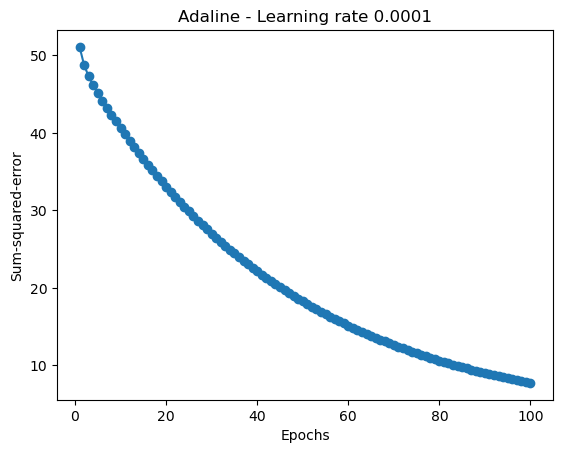

In [5]:
ada3 = AdalineGD(n_iter=100, eta=0.0001).fit(X, y)
plt.plot(range(1, len(ada3.cost_) + 1), ada3.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')
plt.title('Adaline - Learning rate 0.0001')

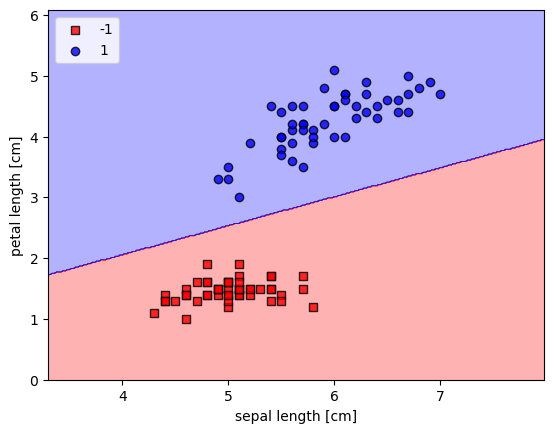

In [6]:
plot_decision_regions(X, y, classifier=ada3)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

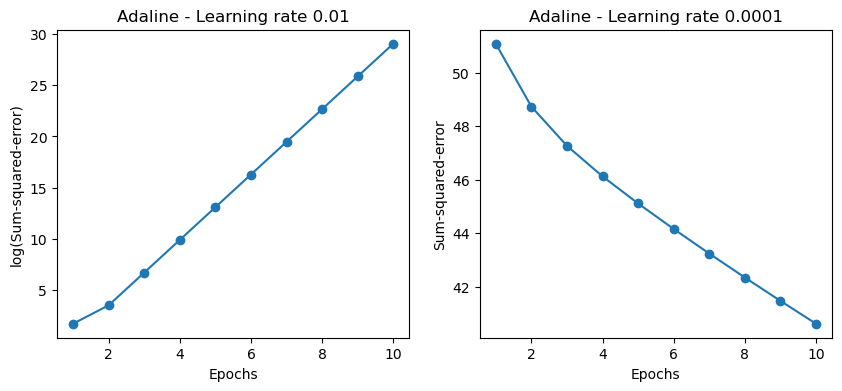

In [7]:
ada1 = AdalineGD(n_iter=10, eta=0.01).fit(X, y)
ada2 = AdalineGD(n_iter=10, eta=0.0001).fit(X, y)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ada1 = AdalineGD(n_iter=10, eta=0.01).fit(X, y)
ax[0].plot(range(1, len(ada1.cost_) + 1), np.log10(ada1.cost_), marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log(Sum-squared-error)')
ax[0].set_title('Adaline - Learning rate 0.01')

ada2 = AdalineGD(n_iter=10, eta=0.0001).fit(X, y)
ax[1].plot(range(1, len(ada2.cost_) + 1), ada2.cost_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Sum-squared-error')
ax[1].set_title('Adaline - Learning rate 0.0001')

# plt.savefig('images/02_11.png', dpi=300)
plt.show()

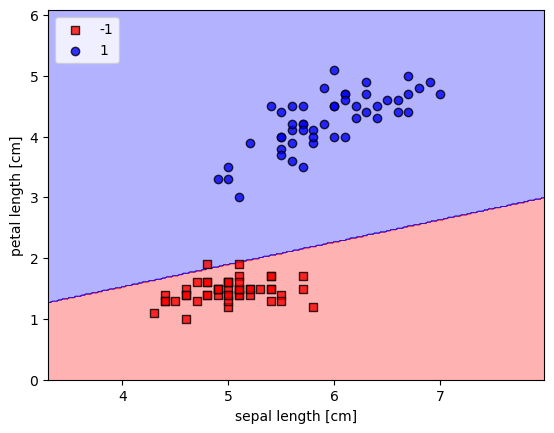

In [8]:
# provare con ada1, ada2 e ada3

ada3 = AdalineGD(n_iter=20, eta=0.0001).fit(X, y)

plot_decision_regions(X, y, classifier=ada3)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

# Logistic Regression

Sia $x$ il vettore delle features e $w$ il vettore dei coefficienti, il valore $w\cdot x = z$ varia nell'intervallo $(-\infty,+\infty)$. Idea: legare questo valore ad una probabilità in modo da avere una misura sulla bontà di una classificazione basata su una probabilità.

Sia $p$ la probabilità della classe positiva (quella classificata con +1) allora $p=Pr(y=1|x)$ ovvero la probabilità che se le features sono $x$ la classe è $+1$.

Definiamo **odd** (quota) il seguente rapporto

$$
\frac{p}{1-p}
$$

questo valore va da $0$ a $+\infty$ e cresce con l'aumentare della probabilità dell'evento. Se passiamo al logaritmo, il valore spazierà tra $-\infty$ e $+\infty$, quindi come $z$. Da questo segue che il valore di $z$ può essere modellato con la funzione **logit**.

$$
logit(p) = \log \left(\frac{p}{1-p}\right) \leftarrow w\cdot x = z
$$

Da questa assunzione possiamo esprimere il valore di $p$ in funzione di $w\cdot x$

$$
\begin{array}{c}
\frac{p}{1-p} = e^z\\
\downarrow\\
p(1 + e^z)=e^z\\
\downarrow\\
p = \frac{1}{1+e^{-z}}
\end{array}
$$

La precedente è chiamata **funzione sigmoide logistica**






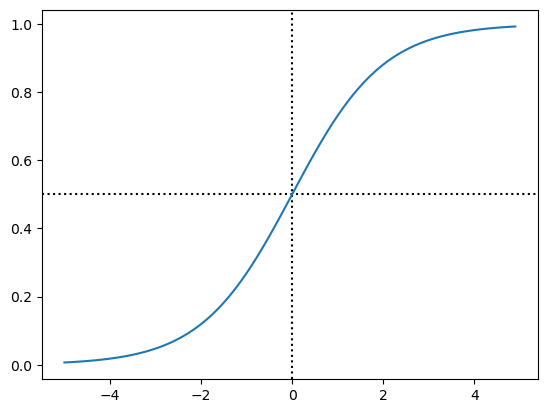

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(z):
    return 1/(1+np.exp(-z))

plt.axvline(0.0, color='k', linestyle=':')
plt.axhline(0.5, color='k', linestyle=':')

z = np.arange(-5, 5, 0.1)
phi_z = sigmoid(z)

plt.plot(z, phi_z)



Questa verrà utilizzata come funzione di attivazione,

$$
\phi(w\cdot x) = \frac{1}{1+e^{w\cdot x}} = Pr(y=1|x)
$$

che può essere usata per definire una funzione soglia per la classificazione

$$
\hat{y}(w\cdot x) = \left\{ \begin{array}{lcl}
+1 & & \text{se}\quad \phi(w\cdot x) > 0.5\\
0 & & \text{altrimenti}
\end{array}
\right.
$$

Il motivo per cui la seconda classe è $0$ e non $-1$ sarà chiarito in seguito.

Tenendo conto dell'andamento della funzione sigmoidale, la precedente espressione è equivalente a

$$
\hat{y}(w\cdot x) = \left\{ \begin{array}{lcl}
+1 & & \text{se}\quad w\cdot x > 0\\
0 & & \text{altrimenti}
\end{array}
\right.
$$

che è la stessa funzione funzione a soglia utilizzata per Adaline.

## Apprendimento dei pesi

Si consideri la seguente espressione

$$
(*) \quad\quad\quad\quad \phi(w\cdot x^{(i)})^{y^{(i)}}(1-\phi(w\cdot x^{(i)}))^{1-y^{(i)}}
$$

- Se $y^{(i)}$ vale $1$, la precedente vale $\phi(w\cdot x^{(i)})$ che è $Pr(y^{(i)} = 1| x)$
- Se $y^{(i)}$ vale $0$, la precedente vale $1-\phi(w\cdot x^{(i)})$ che è $Pr(y^{(i)} =  0| x)$

In definitiva $(*)$ misura sempre la probabilità che l'esempio $i$ venga classificato correttamente. La precedente trattazione spiega anche il motivo del perché la seconda è indicata con  $0$.

Assumendo gli esempi indipendenti gli uni dagli altri, la probabilità di classificare tutti gli esempi in modo corretto è dato dalla seguente funzione chiamata di **verosimiglianza**.

$$
\prod_{i=1}^{n} \phi(w\cdot x^{(i)})^{y^{(i)}}(1-\phi(w\cdot x^{(i)}))^{1-y^{(i)}}
$$

L'obbiettivo è trovare $w$ che massimizzi la precedente espressione. Equivalentemente massimizzeremo il suo logaritmo naturale, ovvero la funzione **log-verosimiglinza**

$$
\sum_{i=1}^{n}\left( y^{(i)}\log\left(\phi(w\cdot x^{(i)})\right) + (1-y^{(i)})\log\left( 1-\phi(w\cdot x^{(i)})\right) \right)
$$

Cambiando di segno la precedente diventa una funzione di costo differenziabile e che può essere minimizzata con discesa del gradiente.

$$
J(w) = -\sum_{i=1}^{n}\left( y^{(i)}\log\left(\phi(w\cdot x^{(i)})\right) + (1-y^{(i)})\log\left( 1-\phi(w\cdot x^{(i)})\right) \right) = -\sum_{i=1}^{n} \ell_i(w)
$$

dove abbiamo indicato con $\ell_i(w)$ la $i$-esima funzione nella sommatoria.

$$
\frac{d}{d w_j}\ell_i(w) = \frac{y^{(i)}}{\phi(w\cdot x^{(i)})} \frac{d}{d w_j} \phi(w\cdot x^{(i)})+
\frac{1-y^{(i)}}{1-\phi(w\cdot x^{(i)})} \left(0 - \frac{d}{d w_j}\phi(w\cdot x^{(i)}) \right)
$$

$$
= \left( \frac{y^{(i)}}{\phi(w\cdot x^{(i)})} - \frac{1-y^{(i)}}{1-\phi(w\cdot x^{(i)})}\right) \frac{d}{d w_j}\phi(w\cdot x^{(i)})
$$

$$
= \frac{y^{(i)} - \phi(w\cdot x^{(i)}) }{\phi(w\cdot x^{(i)}) \left(1-\phi(w\cdot x^{(i)})\right)} \frac{d}{d w_j}\phi(w\cdot x^{(i)})
$$

Per proseguire abbiamo bisogno della derivata parziale di $\phi(w\cdot x^{(i)})$ rispetto a $w_j$.

$$
\frac{d}{d w_j}\phi(w\cdot x^{(i)}) = \frac{d}{d w_j}\frac{1}{1+e^{-w\cdot x^{(i)}}}
$$

applichiamo la regola della derivata del quoziente

$$
= \frac{0(1+e^{-w\cdot x^{(i)}}) - 1(\frac{d}{d w_j}(1+e^{-w\cdot x^{(i)}})) }{\left( 1+e^{-w\cdot x^{(i)}} \right)^2}
$$

Tenendo conto che

$$
\frac{d}{d w_j} e^{-w\cdot x^{(i)}} = e^{-w\cdot x^{(i)}} \frac{d}{d w_j}\left(-w_j\cdot x^{(i)}_j \right) = 
-x_j^{(i)} e^{-w\cdot x^{(i)}}
$$

allora

$$
\frac{d}{d w_j}\phi(w\cdot x^{(i)}) = \frac{x_j^{(i)} e^{-w\cdot x^{(i)}}}{\left( 1+e^{-w\cdot x^{(i)}} \right)^2} = x_j^{(i)} \phi(w\cdot x^{(i)}) \frac{e^{-w\cdot x^{(i)}}}{1+e^{-w\cdot x^{(i)}}}
$$

$$
= x_j^{(i)} \phi(w\cdot x^{(i)}) (1- \phi(w\cdot x^{(i)}))
$$

Sostituendo all'espressione per $\frac{d}{d w_j}\ell_i(w)$

$$
\frac{d}{d w_j}\ell_i(w) = \frac{y^{(i)} - \phi(w\cdot x^{(i)}) }{\phi(w\cdot x^{(i)}) \left(1-\phi(w\cdot x^{(i)})\right)}x_j^{(i)} \phi(w\cdot x^{(i)}) (1- \phi(w\cdot x^{(i)}))
$$

$$
= x_j^{(i)} \left( y^{(i)} - \phi(w\cdot x^{(i)})  \right)
$$

L'aggiornamento dei pesi $w_j$ segue il verso opposto del gradiente ovvero

$$
w_j \leftarrow w_j -\eta \frac{d}{d w_j} J(w)
$$

ma

$$
\frac{d}{d w_j} J(w) = - \sum_{i=1}^{n} x_j^{(i)} \left( y^{(i)} - \phi(w\cdot x^{(i)})  \right)
$$

quindi

$$
w_j \leftarrow w_j +\eta \sum_{i=1}^{n} x_j^{(i)} \left( y^{(i)} - \phi(w\cdot x^{(i)})  \right)
$$

Usando le stesse considerazioni atte per Adaline

$$
w \leftarrow X^T \times \texttt{errors}
$$

Dove il vettore `errors` ha per componenti $y^{(i)} - \phi(w\cdot x^{(i)})$. Notare che quest'ultimo ha la stessa forma dell'analogo di Adaline, la differenza è nella definizione della funzione $\phi$ che nel caso di Adaline è la funzione identità mentre ora è la funzione sigmoid e logistica.

## Codice classe: Logistic Regression

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

class LogisticRegressionGD(object):
    """Logistic Regression Classifier using gradient descent.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
    
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    cost_ : list
      Logistic cost function value in each epoch.

    """
    def __init__(self, eta=0.05, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            
            # note that we compute the logistic `cost` now
            # instead of the sum of squared errors cost
            cost = -y.dot(np.log(output)) - ((1 - y).dot(np.log(1 - output)))
            self.cost_.append(cost)
        
        return self
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, z):
        """Compute logistic sigmoid activation"""
        #return 1. / (1. + np.exp(-np.clip(z, -250, 250)))
        return 1. / (1. + np.exp(-z))

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, 0)
        # equivalent to:
        # return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

0.91


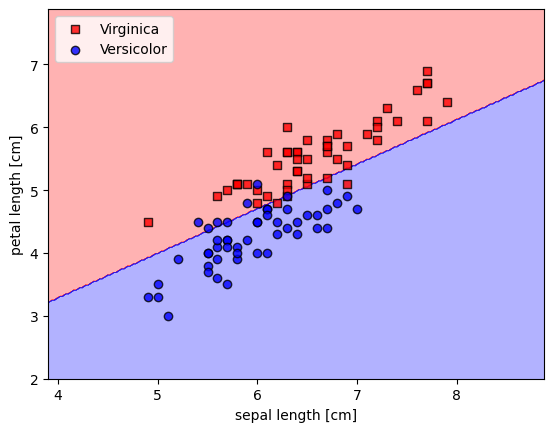

In [11]:
s = os.path.join('dataset', '01-02-iris.csv')
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')

# [0:50] iris-setosa
# [50:100] iris-versicolor
# [100:150] iris-virginica
y = df.iloc[50:, 4].values
y = np.where(y == 'Iris-versicolor', 1, 0)

# extract sepal length and petal length
X = df.iloc[50:, [0, 2]].values



lgrg = LogisticRegressionGD(n_iter=1000, eta=0.001, random_state=1).fit(X, y)

plot_decision_regions(X, y, classifier=lgrg, labels={1:'Versicolor', 0:'Virginica'})

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')
plt.savefig('iris.png', dpi=300)

accuracy = np.mean(lgrg.predict(X) == y)
print(accuracy)

In [12]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X,y = make_classification(n_samples=1000, n_features=10,
                        n_informative=5, n_classes=2, random_state=0, shuffle=False)

# Le informative sono le prime n_informative, poi seguono le altre

X = X [:,:5]

X_train, X_test, y_train, y_test = train_test_split(X, y)

mu, std = X_train.mean(0), X_train.std(0)
X_train_std = (X_train-mu)/std
X_test_std = (X_test-mu)/std

X_train_cur, X_test_cur = X_train, X_test

In [13]:
ada = AdalineGD(n_iter=5000, eta=0.00003, random_state=1)
ada.fit(X_train_cur,y_train)
accuracy = np.mean(ada.predict(X_train_cur) == y_train)
print(accuracy)
accuracy = np.mean(ada.predict(X_test_cur) == y_test)
print(accuracy)

0.4826666666666667
0.54


In [14]:
lgrg = LogisticRegressionGD(n_iter=1000, eta=0.00011, random_state=1)
lgrg.fit(X_train_cur,y_train)
accuracy = np.mean(lgrg.predict(X_train_cur) == y_train)
print(accuracy)
accuracy = np.mean(lgrg.predict(X_test_cur) == y_test)
print(accuracy)

0.908
0.912
